# Simulating data with the Joint Model

In [49]:
import os

import pandas as pd

import leaspy
from leaspy.io.data import Data

leaspy_root = os.path.dirname(leaspy.__file__)

## Import Data



In [50]:
data_path = os.path.join(leaspy_root, "datasets/data/simulated_data_for_joint.csv")

df = pd.read_csv(data_path, dtype={"ID": str}, sep=";")
display(df.head())
print(df.columns)
print("Unique IDs:", len(df["ID"].unique()))

,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,116,78.461,85.5,1,0.44444,0.04,0.0,0.0
1,116,78.936,85.5,1,0.60000,0.00,0.0,0.2
2,116,79.482,85.5,1,0.39267,0.04,0.0,0.2
3,116,79.939,85.5,1,0.58511,0.00,0.0,0.0
4,116,80.491,85.5,1,0.57044,0.00,0.0,0.0


Index(['ID', 'TIME', 'EVENT_TIME', 'EVENT_BOOL', 'Y0', 'Y1', 'Y2', 'Y3'], dtype='object')
Unique IDs: 17


To use the Joint Model in Leaspy, your dataset must include the following columns:

1. **ID** : Patient identifier
2. **TIME** : Time of measurement
3. **EVENT_TIME** : Time of the event
4. **EVENT_BOOL** : Event indicator:
   - `1` if the event occurred
   - `0` if censored
   - `2` if a competing event occurred

For one patient, the event time and event bool are the same for each row.



## Joint Model Initialization and Fitting

In [51]:
from leaspy.models import JointModel

data = Data.from_dataframe(df, "joint")
model = JointModel(name="test_model", nb_events=1)

In [52]:
model.fit(data, "mcmc_saem", seed=1312, n_iter=500, progress_bar=False)

/Users/jv.martini/Documents/leaspy/src/leaspy/models/time_reparametrized.py:288: UserWarning: You did not provide `source_dimension` hyperparameter for multivariate model, setting it to ⌊√dimension⌋ = 2.
  warnings.warn(


 ==> Setting seed to 1312

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 29s


In [53]:
print(model.parameters)

{'betas_mean': tensor([[ 0.0480, -0.1037],
        [ 0.0460, -0.0607],
        [-0.1639, -0.0937]]), 'log_g_mean': tensor([0.1258, 3.0437, 2.7404, 1.2365]), 'log_rho_mean': tensor([1.4383]), 'log_v0_mean': tensor([-3.1961, -3.8937, -3.7175, -2.6191]), 'n_log_nu_mean': tensor([-1.8398]), 'noise_std': tensor(0.0923, dtype=torch.float64), 'tau_mean': tensor([78.9741], dtype=torch.float64), 'tau_std': tensor([6.0641], dtype=torch.float64), 'xi_std': tensor([0.3907], dtype=torch.float64), 'zeta_mean': tensor([[-0.0493],
        [-0.0068]])}


## Simulation

The parameters for simulating patient visits are defined.
These parameters specify the number of patients, the visit spacing, and the timing variability.

In [54]:
visit_params = {
    "patient_number": df["ID"].nunique(),
    "visit_type": "random",
    "first_visit_mean": 0.0,
    "first_visit_std": 0.4,
    "time_follow_up_mean": 6,  
    "time_follow_up_std": 1.2,
    "distance_visit_mean": 2 / 12,
    "distance_visit_std": 0.75 / 12,
    "min_spacing_between_visits": 1,
}

In [55]:
df_sim = model.simulate(
    algorithm="joint_simulate",
    features=["Y0", "Y1", "Y2", "Y3"],
    visit_parameters=visit_params,
)


Simulate with `joint_simulate` took: 0s


In [56]:
df_sim = df_sim.data.to_dataframe()

display(df_sim)

,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,0,76.0,78.652199,1,0.564005,1.029573e-04,1.477032e-01,0.141416
1,0,77.0,78.652199,1,0.660906,6.522695e-02,1.461071e-01,0.302516
2,0,78.0,78.652199,1,0.707631,2.255063e-01,2.555324e-01,0.376017
3,1,76.0,81.941246,1,0.619485,1.998525e-08,5.948373e-07,0.362972
4,1,77.0,81.941246,1,0.435354,2.893412e-03,4.440555e-04,0.385821
...,...,...,...,...,...,...,...,...
85,15,77.0,77.993446,1,0.755295,2.326981e-01,2.889768e-01,0.536983
86,16,83.0,86.634949,1,0.475900,3.059108e-01,1.122353e-10,0.610780
87,16,84.0,86.634949,1,0.411496,1.183114e-04,4.067680e-01,0.683893
88,16,85.0,86.634949,1,0.846075,8.096214e-02,2.129069e-01,0.800922


In [57]:
len(df_sim[df_sim["EVENT_BOOL"] == 0])

40

## Representation witb DTW + UMAP

/Users/jv.martini/Library/Caches/pypoetry/virtualenvs/leaspy-c-kQpk1h-py3.12/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/jv.martini/Library/Caches/pypoetry/virtualenvs/leaspy-c-kQpk1h-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


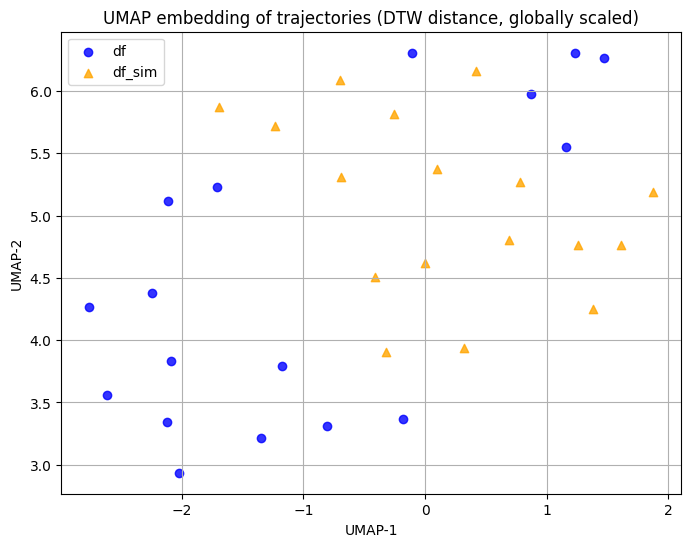

In [58]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tslearn.metrics import cdist_dtw
import umap

# 1. Build trajectories
def build_trajectories(df):
    traj = []
    ids = []
    
    for id_, g in df.groupby('ID'):
        g = g.sort_values('TIME')
        X = g[['Y0','Y1','Y2','Y3']].values
        
        traj.append(X)
        ids.append(id_)
        
    return traj, ids

traj_df, ids_df = build_trajectories(df)
traj_sim, ids_sim = build_trajectories(df_sim)

# Combine
X_all = traj_df + traj_sim
labels = np.array(['df']*len(traj_df) + ['df_sim']*len(traj_sim))

# 2. Normalize globally (fit on all observations combined to preserve scale differences)
all_values = np.vstack(X_all)
scaler = StandardScaler()
scaler.fit(all_values)
scaled_traj = [scaler.transform(X) for X in X_all]

# 3. DTW distance matrix
D = cdist_dtw(scaled_traj)

# 4. UMAP on distance matrix
embedding = umap.UMAP(
    metric='precomputed',
    n_neighbors=15,
    min_dist=0.2,
    random_state=42
).fit_transform(D)

# 5. Plot
mask_df = labels == 'df'
mask_sim = labels == 'df_sim'

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[mask_df, 0],
    embedding[mask_df, 1],
    c='blue',
    marker='o',
    label='df',
    alpha=0.8
)

plt.scatter(
    embedding[mask_sim, 0],
    embedding[mask_sim, 1],
    c='orange',
    marker='^',
    label='df_sim',
    alpha=0.8
)

plt.title("UMAP embedding of trajectories (DTW distance, globally scaled)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True)

plt.show()
